# Maths Lab D — Coordinates, Time & the Sky

!!! info "Before you start"
    **Prerequisites:** Ch 1 (What is Radio Astronomy?) · **Appendix · Maths Lab** · **~40 min** · **Intermediate**

This is an **appendix Maths Lab**, not a chapter. It exists to take a skill that
the main course leans on constantly but never slows down to teach properly —
**knowing where a source is, and when** — and turn it from hand-waving into
something you can compute, plot, and trust. It deepens
[§7 (Coordinates & spherical trigonometry)](../docs/math-preliminaries.md) of the
Mathematical Preliminaries and the **epoch / RA conventions** of
[the Notation reference](../docs/notation.md).

It is tempting to treat coordinates and time as boring bookkeeping you can let a
library handle. You *can* let the library handle it — and you should — but only
once you know **which frame a number lives in** and **what clock it is keeping**.
Almost every confusing bug in observational radio astronomy is really a
coordinate or time bug in disguise:

- a source that "isn't where the catalogue says" (you mixed **J2000** and
  **B1950**, or fed an **hours** RA to code expecting **degrees** — an
  off-by-15 error);
- a target that is "below the horizon" when you expected it up (you used **solar**
  time where the sky keeps **sidereal** time);
- an HI line at "the wrong velocity" (you forgot the **Local Standard of Rest**
  correction — the Earth was moving when you measured it).

This Lab is the worked deep-dive that makes those four ideas — **frames**,
**sidereal time**, **hour angle**, and the **LSR** — concrete.

### What you'll be able to do

- Transform a source between **equatorial (RA/Dec)**, **Galactic**, and
  **horizontal (Alt/Az)** frames with `astropy.coordinates`, and say out loud
  which numbers are fixed to the stars and which change minute to minute.
- Compute **Local Sidereal Time** for a site and instant, and explain — from
  first principles — why a source returns about **four minutes earlier each solar
  day** (Karl Jansky's original clue, [Chapter 1](01_what_is_radio_astronomy.ipynb)).
- Define the **hour angle** $H = \mathrm{LST} - \alpha$, plot a source's Alt/Az
  track across a night, and connect that sweep to how baselines fill the
  $(u,v)$-plane in **Earth-rotation synthesis**
  ([Chapter 8](08_aperture_synthesis.ipynb)).
- Compute an **LSR velocity correction** and understand it as the observer's own
  motion projected onto the line of sight — the correction behind every HI
  velocity in [Chapters 6](06_hydrogen_line.ipynb) and
  [11](11_hi_rotation_curve.ipynb).

> A note on offline operation. This notebook runs **fully offline, with no
> network**. Astropy's coordinate transforms, sidereal-time and radial-velocity
> machinery all work from built-in models for the dates and sites we use. We
> explicitly switch off IERS auto-download so that *nothing* reaches for the
> internet — if a future astropy needs a freshly downloaded Earth-orientation
> table for sub-arcsecond precision it will quietly fall back to the bundled
> table instead of stalling on a download.

**Used by these chapters:** [Ch 10 · Open Archives](10_open_archives.ipynb), [Ch 11 · HI Rotation Curve](11_hi_rotation_curve.ipynb).

## Setup

We pin every random generator and apply the course plot style. The first thing we
do is **disable IERS auto-download** so the whole notebook is guaranteed offline.

In [1]:
# --- Force fully-offline operation BEFORE importing the coordinate machinery ---
from astropy.utils import iers

# Never reach for the network to refresh Earth-orientation / leap-second tables.
iers.conf.auto_download = False
# If a transform would need data newer than the bundled table, extrapolate from
# the built-in table rather than erroring or downloading.
iers.conf.auto_max_age = None

import warnings

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import (
    SkyCoord,
    EarthLocation,
    AltAz,
    Galactic,
    ICRS,
)

# Cosmetic: formatting an RA exactly at the pole (Dec = +90) is degenerate and
# triggers a harmless numpy formatting warning. Silence just that one.
warnings.filterwarnings("ignore", message="invalid value encountered in do_format")

from jansky.plotting import use_jansky_style

use_jansky_style()

# One seeded generator for the whole Lab -> reproducible 'randomness'.
rng = np.random.default_rng(34)

import astropy

print("Offline Coordinates & Time Lab ready.")
print("astropy", astropy.__version__, "| numpy", np.__version__)
print("IERS auto_download =", iers.conf.auto_download, "(False -> no network)")

Offline Coordinates & Time Lab ready.
astropy 8.0.0 | numpy 2.4.6
IERS auto_download = False (False -> no network)


### One site, one instant, three famous sources

To keep everything reproducible we fix a single **observing site** and a single
**reference instant**, and reuse them throughout. The site is the **Karl G.
Jansky Very Large Array** in New Mexico (named, of course, after the man whose
4-minutes-a-day puzzle opened the whole field). We give its latitude, longitude
and height **explicitly** rather than looking it up online, so no network is
needed.

We also define three landmark radio sources by their **J2000** equatorial
coordinates — the modern default frame (ICRS, for practical purposes
indistinguishable from J2000):

- **Cygnus A** — the archetypal radio galaxy, one of the brightest radio sources
  in the sky, high in the northern sky.
- **Sagittarius A\*** — the compact radio source at the **Galactic Centre**, the
  supermassive black hole; it sits essentially *at* Galactic longitude/latitude
  $(0^\circ, 0^\circ)$ by construction.
- The **North Celestial Pole** direction (Dec $=+90^\circ$) — not a source, but a
  useful fixed marker: its Alt/Az never changes as the Earth turns, which makes it
  the perfect sanity check.

We write RA in **hours-minutes-seconds** (`19h59m...`) and Dec in
**degrees-arcmin-arcsec** (`+40d44m...`) — the standard convention. Recall the
trap from the Notation page: $1^\mathrm{h} = 15^\circ$, so handing an hms RA to a
degrees-expecting function is an off-by-15 bug.

In [2]:
# --- A fixed observing site: the Karl G. Jansky VLA, New Mexico ---------------
# Coordinates given explicitly so NO online site lookup is needed.
vla = EarthLocation(
    lat=34.0784 * u.deg,
    lon=-107.6184 * u.deg,  # negative = west
    height=2124 * u.m,
)

# --- A fixed reference instant (UTC) -----------------------------------------
# Northern spring equinox 2024, 06:00 UT. Attaching `location` lets us ask this
# Time object directly for the *local* sidereal time at the VLA.
t0 = Time("2024-03-20T06:00:00", scale="utc", location=vla)

# --- Three landmark directions, in J2000 (ICRS) equatorial coordinates -------
cyg_a = SkyCoord(ra="19h59m28.357s", dec="+40d44m02.10s", frame="icrs")
sgr_a = SkyCoord(ra="17h45m40.04s", dec="-29d00m28.1s", frame="icrs")
ncp = SkyCoord(ra="00h00m00s", dec="+90d00m00s", frame="icrs")  # pole marker

print(f"Site : VLA  lat={vla.lat.to_string()}  lon={vla.lon.to_string()}")
print(f"Time : {t0.isot} UTC")
print()
for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a), ("NCP", ncp)]:
    print(
        f"{name:7s}  RA = {c.ra.to_string(unit=u.hour, sep=':', precision=1):>13s}   "
        f"Dec = {c.dec.to_string(sep=':', precision=1, alwayssign=True):>13s}"
    )

Site : VLA  lat=34d04m42.24s  lon=-107d37m06.24s
Time : 2024-03-20T06:00:00.000 UTC

Cyg A    RA =    19:59:28.4   Dec =   +40:44:02.1
Sgr A*   RA =    17:45:40.0   Dec =   -29:00:28.1
NCP      RA =     0:00:00.0   Dec =   +90:00:00.0


## 2. Celestial coordinates — three frames, one sky

The sky is a sphere, so a position is a pair of **angles**. But there are several
sensible ways to pin down "which way", and they answer different questions. Three
matter to us (Math Preliminaries §7):

| Frame | Coordinates | Fixed to… | Answers |
|-------|-------------|-----------|---------|
| **Equatorial** | Right Ascension $\alpha$, Declination $\delta$ | the stars | "where is it on the celestial sphere?" |
| **Galactic** | longitude $\ell$, latitude $b$ | the Milky Way | "where is it relative to our Galaxy?" |
| **Horizontal** | Altitude (alt), Azimuth (az) | *you*, right now | "where do I point the dish?" |

**Equatorial (RA/Dec)** is the catalogue frame. Declination $\delta$ is celestial
latitude ($-90^\circ$ to $+90^\circ$); Right Ascension $\alpha$ is celestial
longitude, measured eastward in **hours** ($24^\mathrm{h} = 360^\circ$). A
source's RA/Dec **do not change** as the Earth turns — they are stamped to the
stars. Because the frame slowly precesses, you must say *which epoch*: today's
default is **J2000** (equinox 2000.0), essentially the **ICRS** frame astropy uses
by default. Older catalogues used **B1950**, which differs by tenths of a degree —
mixing them is a classic silent error (Notation §5).

**Galactic ($\ell$, $b$)** rotates the same sphere so the plane of the Milky Way
becomes the equator and the Galactic Centre sits at the origin. It is the natural
frame for HI and continuum surveys of our own Galaxy ([Chapter 11](11_hi_rotation_curve.ipynb)).

**Horizontal (Alt/Az)** is what the telescope actually does: altitude above the
horizon and azimuth (compass bearing). These **change minute by minute** as the
Earth rotates, and they depend on **where you are** and **what time it is** — which
is exactly why we needed a fixed site and instant.

The transform between any two of these frames is **spherical trigonometry** — the
law of cosines on a sphere. In practice you never write that by hand; you let
`astropy.coordinates` do it and keep your attention on *which frame a number
lives in*.

### Equatorial → Galactic

This transform is **time-independent**: both frames are fixed to the sky, so no
clock or site is involved. Watch where Sgr A\* lands.

In [3]:
print("Equatorial (J2000)  ->  Galactic\n")
for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a)]:
    g = c.galactic
    print(f"{name:7s}  l = {g.l.degree:8.3f} deg   b = {g.b.degree:+8.3f} deg")

print("\nSgr A* lands at essentially (l, b) = (0, 0) -- it *defines* the")
print("Galactic Centre direction. That is the whole point of the frame.")

Equatorial (J2000)  ->  Galactic

Cyg A    l =   76.190 deg   b =   +5.755 deg
Sgr A*   l =  359.944 deg   b =   -0.046 deg

Sgr A* lands at essentially (l, b) = (0, 0) -- it *defines* the
Galactic Centre direction. That is the whole point of the frame.


### Equatorial → Horizontal (Alt/Az)

This transform **does** need a clock and a place: we build an `AltAz` frame tied to
our site `vla` and instant `t0`, then project each source into it. Altitude tells
you how high above the horizon the source is **at that instant** (negative = below
the horizon, unobservable); azimuth is the compass bearing (0° = North, 90° =
East).

The North Celestial Pole is the sanity check: its altitude **equals the site
latitude** (34.08°) and never moves — the one direction the Earth's rotation
leaves fixed.

In [4]:
altaz_frame = AltAz(obstime=t0, location=vla)

print(f"Horizontal coordinates at the VLA, {t0.isot} UTC\n")
print(f"{'source':8s} {'alt [deg]':>11s} {'az [deg]':>11s}   note")
print("-" * 50)
for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a), ("NCP", ncp)]:
    aa = c.transform_to(altaz_frame)
    up = "up" if aa.alt > 0 * u.deg else "BELOW horizon"
    print(f"{name:8s} {aa.alt.degree:11.2f} {aa.az.degree:11.2f}   {up}")

ncp_alt = ncp.transform_to(altaz_frame).alt
print(f"\nSanity check: NCP altitude = {ncp_alt.degree:.3f} deg")
print(f"             site latitude  = {vla.lat.degree:.3f} deg  (they match)")

Horizontal coordinates at the VLA, 2024-03-20T06:00:00.000 UTC

source     alt [deg]    az [deg]   note
--------------------------------------------------


Cyg A          -6.33       29.70   BELOW horizon
Sgr A*        -28.25      107.54   BELOW horizon
NCP            34.20        0.06   up

Sanity check: NCP altitude = 34.203 deg
             site latitude  = 34.078 deg  (they match)


### A figure: the three sources on the local sky dome

A polar plot is the natural picture of the horizontal frame: azimuth is the
angle around, and altitude maps to the radius (the horizon at the rim, the zenith
at the centre). We sample each source's track over a whole day so you can *see*
which sources rise and set and which never do.

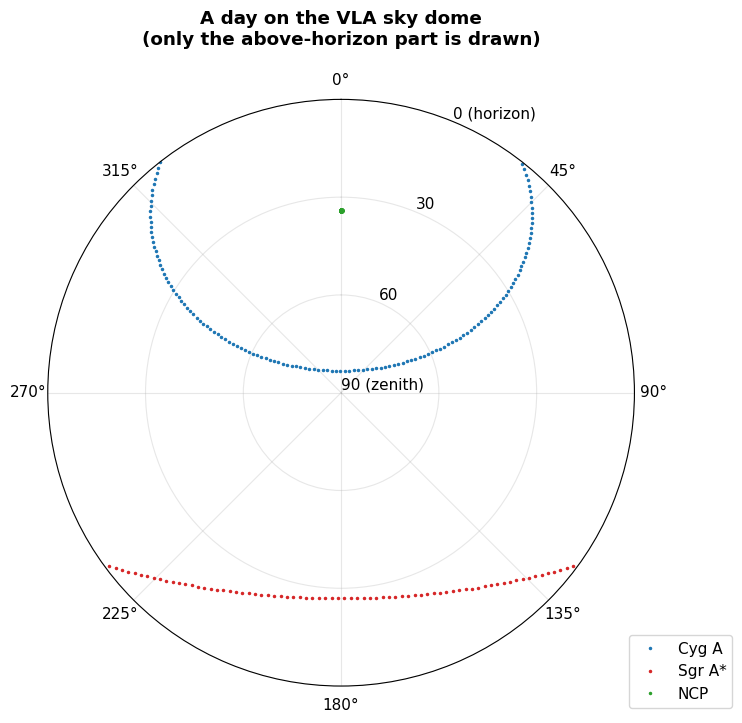

In [5]:
# Sample Alt/Az over 24 h (sidereal motion carries each source around).
hours = np.linspace(0, 24, 200) * u.hour
times = t0 + hours
frames = AltAz(obstime=times[:, np.newaxis], location=vla)

sources = [("Cyg A", cyg_a, "#1f77b4"), ("Sgr A*", sgr_a, "#d62728"), ("NCP", ncp, "#2ca02c")]

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")  # azimuth 0 = North, at the top
ax.set_theta_direction(-1)  # azimuth increases clockwise (N->E->S->W)

for name, c, colour in sources:
    aa = c.transform_to(frames)[:, 0]
    az = aa.az.radian
    # radius = zenith angle: horizon (alt=0) at rim, zenith (alt=90) at centre.
    r = 90.0 - aa.alt.degree
    visible = aa.alt.degree > 0
    ax.plot(az[visible], r[visible], ".", ms=3, color=colour, label=name)

ax.set_rmax(90)
ax.set_rticks([0, 30, 60, 90])
ax.set_yticklabels(["90 (zenith)", "60", "30", "0 (horizon)"])
ax.set_title("A day on the VLA sky dome\n(only the above-horizon part is drawn)", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.18, -0.05))
plt.tight_layout()
plt.show()

Read the figure straight off: **Cyg A** sweeps high across the northern sky (it is
*circumpolar*-ish from this latitude — it barely dips); **Sgr A\*** at Dec
$\approx -29^\circ$ only ever gets modestly above the southern horizon, which is
exactly why the Galactic Centre is hard to study from northern sites; and the
**NCP** sits as a single fixed dot at altitude $=$ latitude, unmoved by the
Earth's spin. Same sky, same instant — three completely different stories,
depending on the frame and the site.

## 3. Sidereal vs solar time — Jansky's four minutes

Now the **time** half of the Lab. The clock on your wall keeps **solar time**: it
is built so the **Sun** returns to the meridian every 24 hours. But the sky's
catalogue frame (RA/Dec) is fixed to the **stars**, not the Sun, and the stars
keep a slightly different clock — **sidereal time**.

The Earth both **spins** on its axis and **orbits** the Sun. In one year it makes
one *extra* spin relative to the stars compared with relative to the Sun. So the
**sidereal day** is shorter than the solar day by

$$
\Delta t \;\approx\; \frac{24\ \mathrm{h}}{365.25} \;\approx\; 3^{\mathrm m}56^{\mathrm s}
\;\approx\; 4\ \text{minutes},
\qquad
T_\mathrm{sid} = 23^{\mathrm h}56^{\mathrm m}04^{\mathrm s} \approx 86164\ \mathrm{s}.
$$

This is **Karl Jansky's clue** ([Chapter 1](01_what_is_radio_astronomy.ipynb)): his
mystery hiss arrived about four minutes earlier each day, which told him the source
was fixed to the *stars* (it turned out to be the Galactic Centre), not to the Sun.

Here we do it with the real machinery. **Local Sidereal Time (LST)** is defined
so that *the RA currently crossing your meridian equals the LST*. So LST is both a
clock and a pointer: **LST tells you which Right Ascension is "up" (on the
meridian) right now.**

In [6]:
# Local Apparent Sidereal Time at the VLA at our reference instant.
lst0 = t0.sidereal_time("apparent")  # uses the site longitude attached to t0
print(f"Local Sidereal Time at the VLA, {t0.isot} UTC:")
print(f"  LST = {lst0.to_string(unit=u.hour, sep=':', precision=1)}")
print()
print("Interpretation: a source with RA equal to this LST is *on the meridian*")
print("(due south, at its highest) at this instant.")

# Which of our sources is closest to the meridian right now?
for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a)]:
    # Hour angle = LST - RA; 0 means 'on the meridian'. Both are angles, so we
    # compare against 0 hourangle (note: u.hourangle, not the *time* unit u.hour).
    ha = (lst0 - c.ra).wrap_at(12 * u.hourangle)
    side = "east, rising" if ha < 0 * u.hourangle else "west, setting"
    print(
        f"  {name:7s}: RA = {c.ra.to_string(unit=u.hour, sep=':', precision=0):>11s}"
        f"  ->  hour angle = {ha.to_string(unit=u.hour, sep=':', precision=1):>11s} "
        f"({side})"
    )

Local Sidereal Time at the VLA, 2024-03-20T06:00:00.000 UTC:
  LST = 10:42:34.9

Interpretation: a source with RA equal to this LST is *on the meridian*
(due south, at its highest) at this instant.
  Cyg A  : RA =    19:59:28  ->  hour angle =  -9:16:53.4 (east, rising)
  Sgr A* : RA =    17:45:40  ->  hour angle =  -7:03:05.1 (east, rising)


### Watching the four minutes accumulate

Let's prove the four-minutes-a-day drift with astropy rather than asserting it. We
take the *same solar clock time* (06:00:00 UT) on a run of consecutive days and
ask for the LST each day. Because the sidereal day is shorter, the LST at a fixed
solar instant **creeps forward by ~4 minutes per day**.

Equivalently: a given source (fixed RA) crosses the meridian when $\mathrm{LST} =
\alpha$, so as LST runs ~4 min fast each day, the source **transits ~4 minutes
earlier on the solar clock each day** — exactly Jansky's signature.

In [7]:
n_days = 10
days = np.arange(n_days)
# Same wall-clock instant (06:00 UT) on each successive day.
sample_times = Time("2024-03-20T06:00:00", scale="utc", location=vla) + days * u.day

lst_hours = sample_times.sidereal_time("apparent").hour
# Unwrap across the 24h boundary so the drift is a clean monotone line.
lst_unwrapped = np.unwrap(lst_hours * (2 * np.pi / 24)) * (24 / (2 * np.pi))
drift_minutes = (lst_unwrapped - lst_unwrapped[0]) * 60.0

# Least-squares slope: minutes of LST gained per solar day.
slope = np.polyfit(days, drift_minutes, 1)[0]

print(f"LST at 06:00 UT on successive days (drift relative to day 0):\n")
for d in range(n_days):
    print(
        f"  day {d:2d}:  LST = {sample_times[d].sidereal_time('apparent').to_string(unit=u.hour, sep=':', precision=0):>11s}"
        f"   (+{drift_minutes[d]:5.1f} min)"
    )
print(f"\nMeasured drift = {slope:.3f} min/day")
print(f"Predicted      = {(24 * 60 / 365.25):.3f} min/day  (24 h / 365.25)")

LST at 06:00 UT on successive days (drift relative to day 0):

  day  0:  LST =    10:42:35   (+  0.0 min)
  day  1:  LST =    10:46:32   (+  3.9 min)
  day  2:  LST =    10:50:28   (+  7.9 min)
  day  3:  LST =    10:54:25   (+ 11.8 min)
  day  4:  LST =    10:58:21   (+ 15.8 min)
  day  5:  LST =    11:02:18   (+ 19.7 min)
  day  6:  LST =    11:06:14   (+ 23.7 min)
  day  7:  LST =    11:10:11   (+ 27.6 min)
  day  8:  LST =    11:14:07   (+ 31.5 min)
  day  9:  LST =    11:18:04   (+ 35.5 min)

Measured drift = 3.942 min/day
Predicted      = 3.943 min/day  (24 h / 365.25)


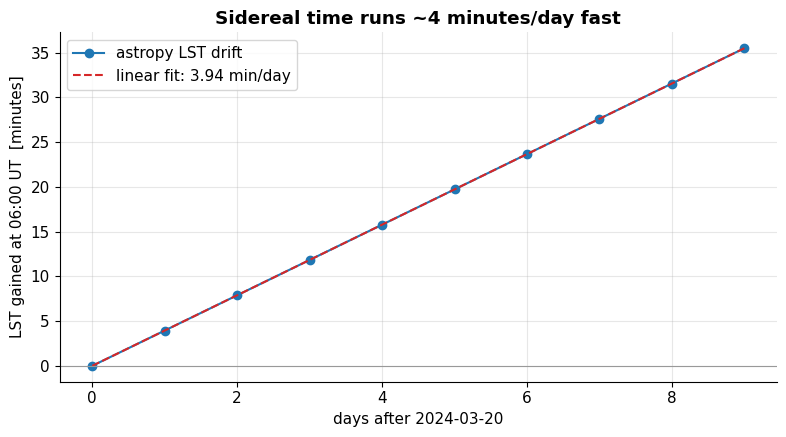

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(days, drift_minutes, "o-", color="#1f77b4", label="astropy LST drift")
ax.plot(days, slope * days, "--", color="#d62728", label=f"linear fit: {slope:.2f} min/day")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("days after 2024-03-20")
ax.set_ylabel("LST gained at 06:00 UT  [minutes]")
ax.set_title("Sidereal time runs ~4 minutes/day fast")
ax.legend()
plt.tight_layout()
plt.show()

A straight line of slope $\approx 3.94$ min/day — the **four minutes** that told
Jansky his static came from the stars. After about a year the accumulated drift
laps a full 24 hours and the sidereal and solar clocks line up again; that one
extra turn *is* the orbit around the Sun.

## 4. Hour angle & Earth-rotation synthesis

The bridge between the catalogue frame (RA/Dec) and the pointing frame (Alt/Az) is
the **hour angle**:

$$
\boxed{\;H \;=\; \mathrm{LST} - \alpha\;}
$$

It measures **how far west of the meridian** a source has rotated, in time units
(or $15^\circ$ per hour). $H = 0$ means the source is **on the meridian** — due
south, at its highest (transit). $H < 0$ means it is **east of the meridian**
(rising); $H > 0$ means **west** (setting). As the Earth turns, $H$ for a fixed
source simply **increases at the sidereal rate**, $15^\circ$ per hour.

Hour angle is the single variable that drives a source's nightly Alt/Az track —
and it is the **same variable that drives Earth-rotation synthesis**. In
[Chapter 8](08_aperture_synthesis.ipynb), a fixed pair of antennas, watched as $H$
sweeps, traces an **arc** through the $(u,v)$-plane: the projection of the baseline
onto the sky rotates with the Earth, so each baseline smears into a curve and the
array fills the Fourier plane *for free* as the night passes. The Alt/Az track and
the $(u,v)$ track are the same Earth rotation seen two ways.

### Hour angle drives the Alt/Az track

We compute Cyg A's hour angle across a night by sampling LST, then plot its
altitude against hour angle. The peak altitude sits exactly at $H = 0$ — the
transit — by definition.

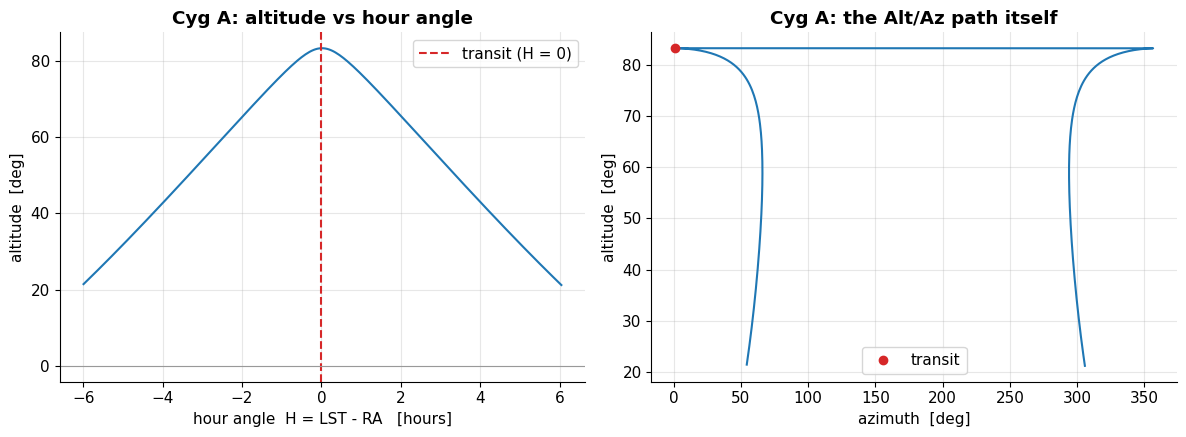

Peak altitude 83.28 deg occurs at H = +0.00 h  (~0, i.e. on the meridian).


In [9]:
# Centre the window on Cyg A's transit so we actually see it cross the meridian.
# The source transits when LST == RA; advance from t0 by (RA - LST0) in sidereal
# hours, then sample +/- 6 h of hour angle on either side of that.
lst0 = t0.sidereal_time("apparent")
hours_to_transit = ((cyg_a.ra - lst0).wrap_at(12 * u.hourangle)).hour
t_transit = t0 + hours_to_transit * u.hour

dt = np.linspace(-6, 6, 240) * u.hour
night = t_transit + dt
lst_night = night.sidereal_time("apparent")

# Hour angle of Cyg A, wrapped to [-12 h, +12 h] (hourangle = an *angle*).
ha_night = (lst_night - cyg_a.ra).wrap_at(12 * u.hourangle)

# Altitude of Cyg A over the same window.
aa_night = cyg_a.transform_to(AltAz(obstime=night, location=vla))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(ha_night.hour, aa_night.alt.degree, color="#1f77b4")
ax1.axvline(0, color="#d62728", ls="--", label="transit (H = 0)")
ax1.axhline(0, color="0.6", lw=0.8)
ax1.set_xlabel("hour angle  H = LST - RA   [hours]")
ax1.set_ylabel("altitude  [deg]")
ax1.set_title("Cyg A: altitude vs hour angle")
ax1.legend()

ax2.plot(aa_night.az.degree, aa_night.alt.degree, color="#1f77b4")
peak = np.argmax(aa_night.alt.degree)
ax2.plot(aa_night.az.degree[peak], aa_night.alt.degree[peak], "o", color="#d62728", label="transit")
ax2.set_xlabel("azimuth  [deg]")
ax2.set_ylabel("altitude  [deg]")
ax2.set_title("Cyg A: the Alt/Az path itself")
ax2.legend()

plt.tight_layout()
plt.show()

ha_at_transit = ha_night.hour[peak]
print(
    f"Peak altitude {aa_night.alt.degree[peak]:.2f} deg occurs at "
    f"H = {ha_at_transit:+.2f} h  (~0, i.e. on the meridian)."
)

### The same rotation sweeps the $(u,v)$-plane

Here is the conceptual punchline of [Chapter 8](08_aperture_synthesis.ipynb),
shown with nothing but rotations. A baseline vector projected onto the plane
perpendicular to the source direction has $(u, v)$ coordinates that depend on the
**hour angle $H$** and the source **declination $\delta$**. For a baseline with
components $(B_x, B_y, B_z)$ (in wavelengths, equatorial), the standard projection
is

$$
\begin{pmatrix} u \\ v \end{pmatrix}
=
\begin{pmatrix}
 \sin H & \cos H \\
 -\sin\delta\cos H & \sin\delta\sin H
\end{pmatrix}
\begin{pmatrix} B_x \\ B_y \end{pmatrix}
\;+\;
\begin{pmatrix} 0 \\ \cos\delta \end{pmatrix} B_z .
$$

As $H$ sweeps through the night, $(u, v)$ traces an **ellipse** — that is the arc
each baseline draws. We plot it for one east–west baseline at two declinations to
show why **sources near the pole give the roundest coverage** (and the roundest
synthesised beam), exactly the point made in Chapter 8.

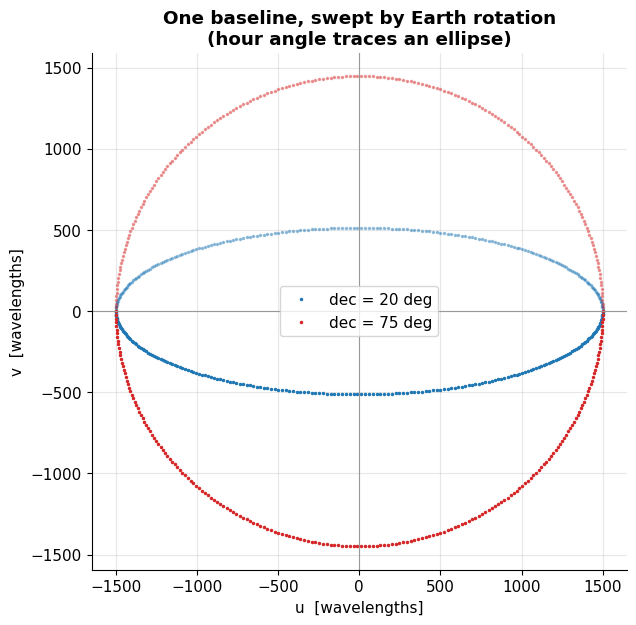

Low declination -> a thin, eccentric ellipse (poor v-coverage).
High declination -> a near-circle -> the 'roundest beam' of Chapter 8.


In [10]:
def uv_track(B_xyz, dec, H):
    "uv coordinates (wavelengths) of a baseline over hour angles H [rad]."
    Bx, By, Bz = B_xyz
    u_ = np.sin(H) * Bx + np.cos(H) * By
    v_ = -np.sin(dec) * np.cos(H) * Bx + np.sin(dec) * np.sin(H) * By + np.cos(dec) * Bz
    return u_, v_


H = np.deg2rad(15.0) * np.linspace(-6, 6, 200)  # +/- 6 h of hour angle, in rad
baseline = (1500.0, 0.0, 0.0)  # an E-W baseline, in wavelengths

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for dec_deg, colour in [(20.0, "#1f77b4"), (75.0, "#d62728")]:
    uu, vv = uv_track(baseline, np.deg2rad(dec_deg), H)
    # The sky is real, so each baseline also gives its conjugate point (-u, -v).
    ax.plot(uu, vv, ".", ms=3, color=colour, label=f"dec = {dec_deg:.0f} deg")
    ax.plot(-uu, -vv, ".", ms=3, color=colour, alpha=0.4)

ax.axhline(0, color="0.6", lw=0.8)
ax.axvline(0, color="0.6", lw=0.8)
ax.set_aspect("equal")
ax.set_xlabel("u  [wavelengths]")
ax.set_ylabel("v  [wavelengths]")
ax.set_title("One baseline, swept by Earth rotation\n(hour angle traces an ellipse)")
ax.legend()
plt.tight_layout()
plt.show()

print("Low declination -> a thin, eccentric ellipse (poor v-coverage).")
print("High declination -> a near-circle -> the 'roundest beam' of Chapter 8.")

## 5. The Local Standard of Rest — why HI velocities need a correction

The last idea is the one that quietly underpins every spectral-line measurement in
[Chapters 6](06_hydrogen_line.ipynb) and [11](11_hi_rotation_curve.ipynb). When you
measure the Doppler shift of the 21 cm HI line, the velocity you get is
contaminated by **your own motion**. The telescope is bolted to an Earth that is

1. **spinning** on its axis (up to ~0.46 km/s at the equator),
2. **orbiting** the Sun (~29.8 km/s), and
3. carried with the Sun's **peculiar motion** through the local stellar
   neighbourhood (~20 km/s).

None of that has anything to do with the gas you are observing. To compare
measurements taken at different times of year — or from different observatories —
you must subtract your own line-of-sight velocity and quote everything in a common
frame. The standard frame is the **Local Standard of Rest (LSR)**: a fiducial
point moving on a circular Galactic orbit at the Sun's position, with the Sun's
peculiar motion removed. The reported quantity is

$$
v_\mathrm{LSR} = v_\mathrm{observed} + v_\mathrm{correction},
$$

where $v_\mathrm{correction}$ is the observer's instantaneous velocity **projected
onto the line of sight to the source**. It is a pure geometry-and-kinematics
calculation — and it changes through the day and the year as the Earth's velocity
vector swings around.

We compute the two pieces astropy gives us:

- the **barycentric** correction (Earth spin + orbit, relative to the Solar System
  barycentre), via `SkyCoord.radial_velocity_correction`; and
- the extra step from the barycentre to the **LSR**, the projection of the Sun's
  standard peculiar motion onto the line of sight.

Their sum is the full $v_\mathrm{LSR}$ correction.

In [11]:
from astropy.coordinates import LSR, CartesianRepresentation


def lsr_correction(coord, obstime, location):
    # Full v_obs -> v_LSR correction along the line of sight, in km/s.
    # Returns (barycentric_part, solar_motion_part, total), all km/s.
    # Sign convention: add the total to an observed radial velocity to put it
    # into the LSR frame.
    # --- (1) Earth spin + orbit, relative to the Solar System barycentre. -----
    # Attach the location to the Time object (astropy's required form here).
    t_loc = Time(obstime.isot, scale="utc", location=location)
    v_bary = coord.radial_velocity_correction(kind="barycentric", obstime=t_loc)

    # --- (2) Barycentre -> LSR: project the standard solar motion on the LOS. --
    # astropy's default LSR carries the standard solar peculiar velocity as a
    # CartesianRepresentation (x, y, z) in the Galactic Cartesian basis, km/s.
    v_sun = LSR().v_bary
    v_sun_cart = u.Quantity([v_sun.x, v_sun.y, v_sun.z])
    # Unit vector to the source in the SAME Galactic Cartesian basis.
    los = coord.galactic.represent_as(CartesianRepresentation)
    los_hat = los / los.norm()
    los_vec = u.Quantity([los_hat.x, los_hat.y, los_hat.z])
    v_solar = np.dot(v_sun_cart, los_vec)  # component of solar motion along LOS

    total = v_bary.to(u.km / u.s) + v_solar.to(u.km / u.s)
    return v_bary.to(u.km / u.s), v_solar.to(u.km / u.s), total


for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a)]:
    v_b, v_s, v_tot = lsr_correction(c, t0, vla)
    print(
        f"{name:7s}  barycentric = {v_b: .3f}   solar->LSR = {v_s: .3f}   "
        f"total v_LSR corr = {v_tot: .3f}"
    )
print("\n(Add 'total' to a measured radial velocity to express it in the LSR frame.)")

Cyg A    barycentric =  10.246 km / s   solar->LSR =  15.190 km / s   total v_LSR corr =  25.435 km / s
Sgr A*   barycentric =  30.077 km / s   solar->LSR =  11.082 km / s   total v_LSR corr =  41.160 km / s

(Add 'total' to a measured radial velocity to express it in the LSR frame.)


### The correction is not a constant — it breathes with the year

Because the dominant term is the Earth's **orbital** velocity (~30 km/s), the
projected correction swings by tens of km/s over a year as the Earth's velocity
vector rotates around the Sun. That is why a survey re-observing the same HI cloud
in different months sees the raw line at different velocities — and why the LSR
correction is not optional. We trace the barycentric correction for Cyg A across a
full year.

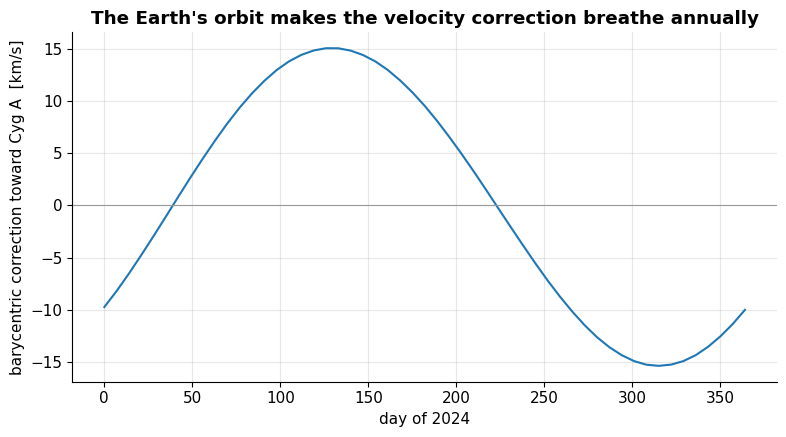

Peak-to-peak annual swing: 30.4 km/s (~2 x the orbital speed projected on this line of sight).


In [12]:
months = np.arange(0, 366, 7)
year_times = Time("2024-01-01T00:00:00", scale="utc") + months * u.day

corr = []
for tt in year_times:
    t_loc = Time(tt.isot, scale="utc", location=vla)
    v = cyg_a.radial_velocity_correction(kind="barycentric", obstime=t_loc)
    corr.append(v.to_value(u.km / u.s))
corr = np.array(corr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(months, corr, color="#1f77b4")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("day of 2024")
ax.set_ylabel("barycentric correction toward Cyg A  [km/s]")
ax.set_title("The Earth's orbit makes the velocity correction breathe annually")
plt.tight_layout()
plt.show()

print(
    f"Peak-to-peak annual swing: {corr.max() - corr.min():.1f} km/s "
    f"(~2 x the orbital speed projected on this line of sight)."
)

For an HI line whose intrinsic features span only a few to tens of km/s, a swing of
this size is the difference between a clean rotation curve and nonsense — which is
why `v_LSR` is the velocity axis you will always see plotted in
[Chapter 11](11_hi_rotation_curve.ipynb), never the raw observed velocity.

## Try it yourself

1. **The off-by-15 bug, made real.** Re-create Cyg A but *wrongly* feed its RA as
   if the hours were degrees:
   `SkyCoord(ra=19.99*u.deg, dec=40.73*u.deg)` versus the correct
   `SkyCoord(ra=19.99*u.hourangle, dec=40.73*u.deg)`. Transform both to Galactic
   and to Alt/Az at `t0`. How far apart do they land, and which famous
   factor-of-15 mistake does this reproduce (Notation §5)?

2. **Your own meridian clock.** Pick *your* latitude/longitude (build an
   `EarthLocation` with explicit numbers — no network) and tonight's date. Compute
   the LST, and from it work out **which Right Ascension is on your meridian right
   now**. Then list which of Cyg A / Sgr A\* is currently above your horizon. Does
   it match the polar sky-dome logic from Section 2?

3. **Round beams near the pole.** In the $(u,v)$-ellipse code of Section 4, sweep
   the source declination from $0^\circ$ to $90^\circ$ and, for each, measure the
   **ratio of the ellipse's minor to major axis** of the swept track. Confirm that
   it tends to $\sin\delta$ — the same $\sin(\delta)$ squash named in Math
   Preliminaries §7 — and explain why $\delta = 90^\circ$ gives a perfect circle.

4. **(Stretch) LSR over a day, not a year.** Hold the date fixed and sweep the
   *hour* of observation across 24 h for a fixed source. Plot the barycentric
   correction. You should see a small (~$\pm 0.4$ km/s) daily ripple riding on the
   orbital term — the Earth's **spin** contribution. Which observatory latitude
   maximises it?

<details><summary>Solution 1</summary>

Build the two `SkyCoord`s — one wrongly treating the RA value as **degrees**, one correctly as **hourangle** — and compare them. The right RA is $19.99^\mathrm{h} = 299.85^\circ$, but the wrong one sits at $19.99^\circ$; their RA differs by exactly the factor $1^\mathrm{h}=15^\circ$, so the two land far apart on the sky. Transform both to Galactic and Alt/Az at `t0` to see how badly the error propagates.

```python
wrong = SkyCoord(ra=19.99 * u.deg,       dec=40.73 * u.deg)  # BUG: hours fed as degrees
right = SkyCoord(ra=19.99 * u.hourangle, dec=40.73 * u.deg)  # correct: RA in hours

# How far apart on the sky?
sep = wrong.separation(right)
print(f"On-sky separation between the two: {sep.degree:.1f} deg")
print(f"RA: wrong = {wrong.ra.deg:.2f} deg,  right = {right.ra.deg:.2f} deg"
      f"  (ratio = {right.ra.deg / wrong.ra.deg:.1f})\n")

altaz_frame = AltAz(obstime=t0, location=vla)
for label, c in [("wrong (deg)", wrong), ("right (hms)", right)]:
    g = c.galactic
    aa = c.transform_to(altaz_frame)
    print(f"{label:11s}  l = {g.l.degree:7.2f}  b = {g.b.degree:+6.2f}   "
          f"alt = {aa.alt.degree:+6.2f}  az = {aa.az.degree:6.2f}")
```

**Expected:** the two positions are ~**58°** apart on the sky, with RA differing by exactly a factor of **15** (299.85° vs 19.99°). They land in completely different Galactic and Alt/Az positions. This is the classic **$1^\mathrm{h}=15^\circ$ off-by-15 RA bug** from Notation §5 — handing an hours-valued RA to code that expects degrees (or vice versa).

</details>

<details><summary>Solution 2</summary>

Build an `EarthLocation` with explicit numbers (no network), attach it to a `Time`, and ask for the **apparent sidereal time**. By definition $\mathrm{LST}$ equals the RA currently on the meridian. Then project Cyg A and Sgr A* into an `AltAz` frame at your site and instant to see which is up. Replace the latitude/longitude/date below with your own.

```python
# --- Your site and instant (edit these) ---
mysite = EarthLocation(lat=51.4779 * u.deg, lon=-0.0015 * u.deg, height=46 * u.m)  # Greenwich
t_now = Time("2026-06-21T22:00:00", scale="utc", location=mysite)

# LST = the RA on your meridian right now.
lst = t_now.sidereal_time("apparent")
print(f"Local Sidereal Time = {lst.to_string(unit=u.hour, sep=':', precision=0)}")
print(f"-> RA {lst.to_string(unit=u.hour, sep=':', precision=0)} is on your meridian (due south, highest).\n")

# Which landmark sources are above your horizon?
altaz_here = AltAz(obstime=t_now, location=mysite)
for name, c in [("Cyg A", cyg_a), ("Sgr A*", sgr_a)]:
    aa = c.transform_to(altaz_here)
    up = "up" if aa.alt > 0 * u.deg else "BELOW horizon"
    print(f"{name:7s}  alt = {aa.alt.degree:+6.2f} deg   az = {aa.az.degree:6.2f} deg   {up}")
```

**Expected:** `LST` prints in hms and *is* the RA on your meridian. At the example site/instant (Greenwich, 2026-06-21 22:00 UT) the LST is ~16h00m, both Cyg A (Dec $+40^\circ$, alt ~48°) and Sgr A* (Dec $-29^\circ$, alt ~6°) are just up. This matches Section 2's logic: a northern site sees high-Dec Cyg A easily, while low-Dec Sgr A* only ever skims the southern horizon.

</details>

<details><summary>Solution 3</summary>

Reuse the `uv_track` helper from Section 4. Sweep the source declination from $0^\circ$ to $90^\circ$; for each, the Earth-rotation track is an ellipse whose **major axis** lies along $u$ (unaffected by $\delta$ for this E–W baseline) and whose **minor axis** along $v$ is squashed by exactly $\sin\delta$. Measuring (half-range in $v$) / (half-range in $u$) over a full $\pm12$ h sweep recovers $\sin\delta$.

```python
# uv_track is defined in Section 4; an E-W baseline in wavelengths.
baseline = (1500.0, 0.0, 0.0)
H = np.deg2rad(15.0) * np.linspace(-12, 12, 2000)   # full +/-12 h sweep

decs = np.arange(0, 91, 5)
ratios = []
for dec_deg in decs:
    uu, vv = uv_track(baseline, np.deg2rad(dec_deg), H)
    major = (uu.max() - uu.min()) / 2   # along u
    minor = (vv.max() - vv.min()) / 2   # along v
    ratios.append(minor / major if major > 0 else np.nan)
ratios = np.array(ratios)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(decs, ratios, "o", color="#1f77b4", label="measured minor/major")
ax.plot(decs, np.sin(np.deg2rad(decs)), "-", color="#d62728", label=r"$\sin\delta$")
ax.set_xlabel("declination  [deg]")
ax.set_ylabel("ellipse axis ratio (minor/major)")
ax.set_title("Earth-rotation uv-ellipse axis ratio tends to sin(dec)")
ax.legend()
plt.tight_layout()
plt.show()

for dec_deg in (0, 45, 90):
    uu, vv = uv_track(baseline, np.deg2rad(dec_deg), H)
    r = ((vv.max()-vv.min())/2) / ((uu.max()-uu.min())/2)
    print(f"dec = {dec_deg:2d} deg  ->  minor/major = {r:.3f}   sin(dec) = {np.sin(np.deg2rad(dec_deg)):.3f}")
```

**Expected:** the measured points fall exactly on the $\sin\delta$ curve (0 at $\delta=0^\circ$, $\approx0.707$ at $45^\circ$, 1 at $90^\circ$). At $\delta=90^\circ$ the source is at the pole, so the projected baseline rotates in a plane fully facing the observer — the ellipse becomes a **perfect circle** ($\sin 90^\circ = 1$), giving the roundest $(u,v)$ coverage and the roundest synthesised beam (Chapter 8).

</details>

<details><summary>Solution 4</summary>

Hold the date fixed and sweep the *hour* of observation. The barycentric correction is dominated by the Earth's ~30 km/s orbital motion (constant over a single day), so over 24 h you see only a small ripple from the Earth's **spin** — the observer is carried east at up to ~0.46 km/s at the equator, projected onto the line of sight. The spin term scales with $\cos(\text{latitude})$, so an **equatorial** site ($\text{lat}=0^\circ$) maximises it.

```python
# Same fixed date, sweep the hour across 24 h for a fixed source (Cyg A).
hours = np.linspace(0, 24, 96) * u.hour
day_times = Time("2024-03-20T00:00:00", scale="utc") + hours

corr = []
for tt in day_times:
    t_loc = Time(tt.isot, scale="utc", location=vla)
    v = cyg_a.radial_velocity_correction(kind="barycentric", obstime=t_loc)
    corr.append(v.to_value(u.km / u.s))
corr = np.array(corr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hours.value, corr - corr.mean(), color="#1f77b4")
ax.set_xlabel("hour of 2024-03-20  [UT]")
ax.set_ylabel("barycentric correction toward Cyg A,\nmean removed  [km/s]")
ax.set_title("The Earth's spin adds a small daily ripple")
plt.tight_layout()
plt.show()

print(f"Daily peak-to-peak ripple: {corr.max() - corr.min():.3f} km/s")
print("Latitude that maximises it: 0 deg (equator), where the full")
print("equatorial spin speed (~0.46 km/s) can project onto the line of sight.")
```

**Expected:** a smooth ~24 h sinusoid with a peak-to-peak amplitude of roughly **0.6 km/s** (here ~0.59 km/s for Cyg A), riding on the much larger, day-constant orbital term. The amplitude shrinks toward the poles as $\cos(\text{latitude})$ and is largest at the **equator**.

</details>

## Recap & where this feeds back in

- **A position is a pair of angles, but you must say *in which frame*.**
  Equatorial (RA/Dec, J2000) is fixed to the stars; Galactic ($\ell, b$) is fixed
  to the Milky Way; horizontal (Alt/Az) is fixed to *you* and changes minute by
  minute. We transformed Cyg A, Sgr A\* and the pole between all three with
  `astropy.coordinates`, and saw Sgr A\* land at the Galactic-Centre origin
  $(0^\circ, 0^\circ)$ by construction.
- **The sky keeps sidereal time.** Because the Earth orbits as it spins, the
  sidereal day is ~4 minutes short of the solar day, so a fixed source transits ~4
  minutes earlier each day — **Karl Jansky's original clue**
  ([Chapter 1](01_what_is_radio_astronomy.ipynb)), which we reproduced by asking
  astropy for the LST on successive days. **LST tells you which RA is on the
  meridian.**
- **Hour angle $H = \mathrm{LST} - \alpha$** is the one variable that drives both a
  source's nightly Alt/Az track *and* the way a baseline sweeps the
  $(u,v)$-plane in **Earth-rotation synthesis**
  ([Chapter 8](08_aperture_synthesis.ipynb)). Same rotation, two pictures — and
  high-declination sources give the roundest coverage.
- **The LSR correction** removes the observer's own motion (Earth spin + orbit +
  solar peculiar motion) projected onto the line of sight, so HI velocities are
  comparable across time and place. It *breathes* by tens of km/s over a year,
  which is why $v_\mathrm{LSR}$ — not raw velocity — is the axis of every spectrum
  in [Chapters 6](06_hydrogen_line.ipynb) and [11](11_hi_rotation_curve.ipynb).

Everything here ran **offline**, from astropy's built-in Earth and ephemeris
models — no catalogue query, no IERS download. The skill it buys you is small but
constant: whenever a source is "in the wrong place" or "at the wrong velocity",
your first question is now *which frame, and which clock?*